<a href="https://colab.research.google.com/github/Kurtoglumuhammet/Fresnel-planck-spektral-analiz/blob/main/Fresnel_planck_spektral_analiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FRESNEL SOĞURMA & PLANCK RADYASYON SPEKTRAL ANALİZ MODELİ
Hesaplamalar tamamlandı. Grafikler çiziliyor...
Grafik 'fresnel_planck_analiz.png' olarak kaydedildi.


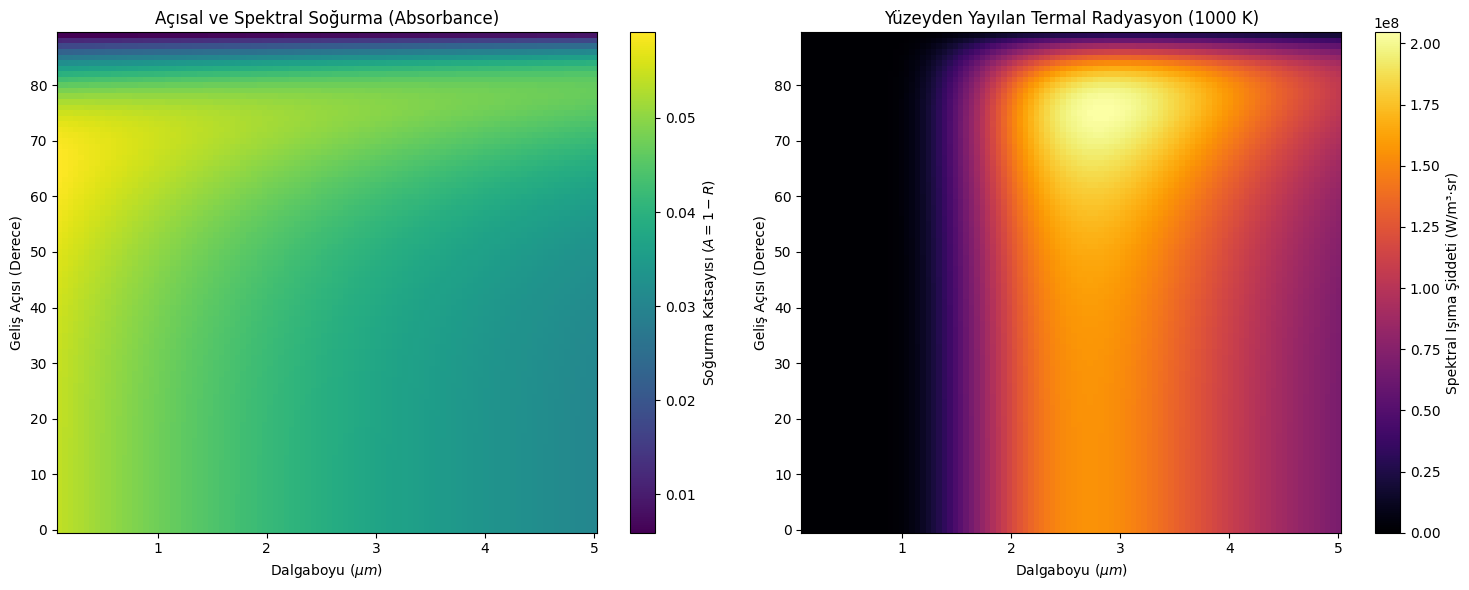

In [2]:
#Yazar: (proje sahibi)
#"Muhammet Kurtoğlu"

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from numpy.typing import NDArray

PLANCK_SABITI = 6.62607015e-34   # h, Planck sabiti (J·s)
ISIK_HIZI = 299792458.0          # c, boşlukta ışık hızı (m/s)
BOLTZMANN_SABITI = 1.380649e-23  # k_B, Boltzmann sabiti (J/K)

T_YUZEY_VARSAYILAN = 1000.0   # Yüzey sıcaklığı (Kelvin)
N1_VARSAYILAN = 1.0           # Geliş ortamının kırıcılık indisi (hava/vakum)

DALGABOYU_MIN_UM = 0.1        # Dalgaboyu tarama aralığı alt sınırı (mikron)
DALGABOYU_MAX_UM = 5.0        # Dalgaboyu tarama aralığı üst sınırı (mikron)
DALGABOYU_NOKTA_SAYISI = 100

ACI_MIN_DERECE = 0.0          # Geliş açısı tarama aralığı alt sınırı
ACI_MAX_DERECE = 89.0         # 90 derecede sin/cos tekilliği önlenir
ACI_NOKTA_SAYISI = 90


def planck_yasasi(
    dalgaboyu_m: NDArray[np.float64], sicaklik_K: float
) -> NDArray[np.float64]:
    """Verilen dalgaboyuları ve sıcaklık için kara cisim spektral ışıma
    şiddetini hesaplar (Planck'ın ışıma yasası).

    Parametreler
    dalgaboyu_m : ndarray
        Dalgaboyu değerleri, metre cinsinden.
    sicaklik_K : float
        Kara cismin yüzey sıcaklığı, Kelvin cinsinden.

    Döndürür
    ndarray
        Spektral ışıma şiddeti, W/m³·sr biriminde (her dalgaboyu için).
    """
    pay = (2.0 * PLANCK_SABITI * ISIK_HIZI**2) / (dalgaboyu_m**5)
    payda = np.expm1((PLANCK_SABITI * ISIK_HIZI) / (dalgaboyu_m * BOLTZMANN_SABITI * sicaklik_K))
    return pay / payda


def hipotetik_kirilma_indisi(dalgaboyu_um: NDArray[np.float64]) -> NDArray[np.complex128]:
    """Metal benzeri (gümüş benzeri) hipotetik kompleks kırılma indisini
    dalgaboyuna bağlı olarak üretir.

    Önemli Not: Gerçek projede bu değerler bir .m / .csv dosyasından okunan ölçülmüş
    n, k verileriyle değiştirilebilir. Burada model bağımsız çalışabilsin diye
    dalgaboyuna doğrusal bağlı hipotetik bir yaklaşım kullanılmıştır.

    Parametreler
    dalgaboyu_um : ndarray
        Dalgaboyu değerleri, mikron cinsinden.

    Döndürür
    ndarray (complex)
        n + i*k şeklinde kompleks kırılma indisi dizisi.
    """
    n_kismi = 0.15 + 0.02 * dalgaboyu_um
    k_kismi = 3.10 + 0.5 * dalgaboyu_um
    return n_kismi + 1j * k_kismi


def fresnel_sogurma_hesapla(
    acilar_rad: NDArray[np.float64],
    n2_kompleks: NDArray[np.complex128],
    n1: float = N1_VARSAYILAN,
) -> NDArray[np.float64]:
    """Her (açı, dalgaboyu) çifti için s- ve p-polarizasyonlarının ortalama
    Fresnel soğurma katsayısını vektörize biçimde hesaplar.

    Parametreler
    acilar_rad : ndarray, shape (N_aci,)
        Geliş açıları, radyan cinsinden.
    n2_kompleks : ndarray, shape (N_dalgaboyu,)
        İkinci ortamın (yüzeyin) kompleks kırılma indisi, her dalgaboyu için.
    n1 : float
        İlk ortamın (geliş ortamının) kırıcılık indisi.

    Döndürür
    ndarray, shape (N_aci, N_dalgaboyu)
        Soğurma katsayısı matrisi (A = 1 - R_ortalama).
    """
    # Broadcasting için açı sütun vektörü, n2 satır vektörü olarak hizalanır.
    theta = acilar_rad[:, np.newaxis]          # shape: (N_aci, 1)
    n2 = n2_kompleks[np.newaxis, :]            # shape: (1, N_dalgaboyu)

    sin_theta_i = np.sin(theta)
    cos_theta_i = np.cos(theta)

    sin_theta_t = (n1 / n2) * sin_theta_i
    # +0j ile karekök dalı stabil tutulur (toplam iç yansımada kompleks sonuç verir).
    cos_theta_t = np.sqrt(1 - sin_theta_t**2 + 0j)

    # s-polarizasyonu (TE) ve p-polarizasyonu (TM) yansıma katsayıları
    rs = (n1 * cos_theta_i - n2 * cos_theta_t) / (n1 * cos_theta_i + n2 * cos_theta_t)
    rp = (n2 * cos_theta_i - n1 * cos_theta_t) / (n2 * cos_theta_i + n1 * cos_theta_t)

    yansima_ortalama = (np.abs(rs) ** 2 + np.abs(rp) ** 2) / 2.0
    sogurma_ortalama = 1.0 - yansima_ortalama
    return sogurma_ortalama


def spektral_analiz_calistir(
    t_yuzey: float = T_YUZEY_VARSAYILAN,
    n1: float = N1_VARSAYILAN,
    dalgaboyu_um: NDArray[np.float64] | None = None,
    acilar_derece: NDArray[np.float64] | None = None,
) -> tuple[NDArray[np.float64], NDArray[np.float64], NDArray[np.float64], NDArray[np.float64]]:
    """Fresnel soğurma ve Planck radyasyon hesaplarını birleştirerek tam
    (açı x dalgaboyu) matrislerini üretir.

    Parametreler
    t_yuzey : float
        Yüzey sıcaklığı (Kelvin).
    n1 : float
        Geliş ortamının kırıcılık indisi.
    dalgaboyu_um : ndarray veya None
        Taranacak dalgaboyu değerleri (mikron). None ise varsayılan aralık kullanılır.
    acilar_derece : ndarray veya None
        Taranacak geliş açıları (derece). None ise varsayılan aralık kullanılır.

    Döndürür
    tuple
        (dalgaboyu_um, acilar_derece, A_matrix, E_matrix)
        A_matrix : soğurma katsayısı matrisi, shape (N_aci, N_dalgaboyu)
        E_matrix : yayılan spektral ışıma matrisi, shape (N_aci, N_dalgaboyu)
    """
    if dalgaboyu_um is None:
        dalgaboyu_um = np.linspace(DALGABOYU_MIN_UM, DALGABOYU_MAX_UM, DALGABOYU_NOKTA_SAYISI)
    if acilar_derece is None:
        acilar_derece = np.linspace(ACI_MIN_DERECE, ACI_MAX_DERECE, ACI_NOKTA_SAYISI)

    dalgaboyu_m = dalgaboyu_um * 1e-6
    acilar_rad = np.radians(acilar_derece)

    n2_kompleks = hipotetik_kirilma_indisi(dalgaboyu_um)

    # --- Fresnel soğurma matrisi: shape (N_aci, N_dalgaboyu) ---
    A_matrix = fresnel_sogurma_hesapla(acilar_rad, n2_kompleks, n1=n1)

    # --- Planck kara cisim ışıması: her dalgaboyu için tek satır, sonra
    #     açı boyutuna broadcast edilir (yayılan ışıma açıdan bağımsızdır,
    #     sadece soğurma/emissivity ile ölçeklenir) ---
    I_blackbody = planck_yasasi(dalgaboyu_m, t_yuzey)  # shape: (N_dalgaboyu,)
    E_matrix = A_matrix * I_blackbody[np.newaxis, :]   # Kirchhoff Yasası: ε = A

    return dalgaboyu_um, acilar_derece, A_matrix, E_matrix


def grafikleri_ciz(
    dalgaboyu_um: NDArray[np.float64],
    acilar_derece: NDArray[np.float64],
    A_matrix: NDArray[np.float64],
    E_matrix: NDArray[np.float64],
    t_yuzey: float = T_YUZEY_VARSAYILAN,
) -> Figure:
    """Soğurma ve yayılan radyasyon matrislerini yan yana iki ısı haritası
    (colormap) olarak çizer.

    Döndürür
    matplotlib.figure.Figure
        Oluşturulan figür nesnesi (kaydetmek veya göstermek için kullanılabilir).
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    X, Y = np.meshgrid(dalgaboyu_um, acilar_derece)

    # 1. Grafik: Spektral Soğurma (Absorbance) Haritası
    c1 = ax1.pcolormesh(X, Y, A_matrix, cmap="viridis", shading="auto")
    ax1.set_title("Açısal ve Spektral Soğurma (Absorbance)")
    ax1.set_xlabel(r"Dalgaboyu ($\mu m$)")
    ax1.set_ylabel("Geliş Açısı (Derece)")
    fig.colorbar(c1, ax=ax1, label="Soğurma Katsayısı ($A = 1 - R$)")

    # 2. Grafik: Yayılan Termal Radyasyon (Emitted Radiation)
    c2 = ax2.pcolormesh(X, Y, E_matrix, cmap="inferno", shading="auto")
    ax2.set_title(f"Yüzeyden Yayılan Termal Radyasyon ({t_yuzey:.0f} K)")
    ax2.set_xlabel(r"Dalgaboyu ($\mu m$)")
    ax2.set_ylabel("Geliş Açısı (Derece)")
    fig.colorbar(c2, ax=ax2, label=r"Spektral Işıma Şiddeti (W/m³·sr)")

    fig.tight_layout()
    return fig


def main() -> None:
    print("=" * 60)
    print("FRESNEL SOĞURMA & PLANCK RADYASYON SPEKTRAL ANALİZ MODELİ")
    print("=" * 60)

    dalgaboyu_um, acilar_derece, A_matrix, E_matrix = spektral_analiz_calistir()

    print("Hesaplamalar tamamlandı. Grafikler çiziliyor...")
    fig = grafikleri_ciz(dalgaboyu_um, acilar_derece, A_matrix, E_matrix)

    cikti_dosyasi = "fresnel_planck_analiz.png"
    fig.savefig(cikti_dosyasi, dpi=150)
    print(f"Grafik '{cikti_dosyasi}' olarak kaydedildi.")

    plt.show()


if __name__ == "__main__":
    main()